In [1]:
!wget --no-cache -O init.py -q https://raw.githubusercontent.com/UDEA-Esp-Analitica-y-Ciencia-de-Datos/EACD-08-CLOUD/master/init.py
import init; init.init(force_download=False);
from IPython.display import Image

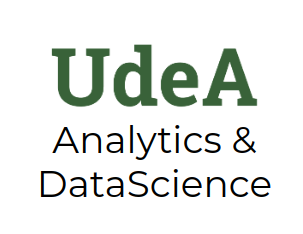

In [2]:
Image("local/imgs/udea-datascience.png")

# **PRÁCTICA 1: SERIALIZACIÓN DE DATOS**
## Desarrollado por: Mg. Efraín Alberto Oviedo
## Universidad de Antioquia

Por favor, ingrese la siguiente información:

**Nombre Completo:** Camilo Valencia

**Cédula:** —

**Correo Institucional:** camilo.valencia@ciudadela.eu

# **Análisis de ventas y garantías**

Una reconocida empresa de electrodomésticos caracterizada por la calidad de sus productos, desea analizar la información relacionada con los servicios de venta y garantía prestados a sus clientes.

La empresa cuenta con tiendas físicas y virtuales distribuidas a lo largo del país y su objetivo es canalizar la información relacionada con los servicios ofrecidos incluyendo los comentarios y calificaciones que logra recoger de cada uno de los servicios prestados.

Se solicita su ayuda para realizar las siguientes actividades:

## **A) Definición de variables a recolectar**

A continuación se definen las variables que se deben recolectar en cada tipo de servicio:

---

### Servicio de **VENTA**

| Variable | Tipo | Descripción |
|---|---|---|
| `id_venta` | Entero | Identificador único de la transacción |
| `fecha` | Cadena (YYYY-MM-DD) | Fecha en que se realizó la venta |
| `nombre_cliente` | Cadena | Nombre completo del comprador |
| `telefono_cliente` | Cadena | Teléfono de contacto del cliente |
| `email_cliente` | Cadena | Correo electrónico del cliente |
| `nombre_producto` | Cadena | Nombre comercial del electrodoméstico vendido |
| `categoria` | Cadena | Categoría del producto (Refrigeración, Lavado, Audio/Video, etc.) |
| `precio` | Real | Precio final de venta en pesos colombianos |
| `cantidad` | Entero | Número de unidades adquiridas |
| `metodo_pago` | Cadena | Forma de pago (Efectivo, Tarjeta crédito, Tarjeta débito, Financiación) |
| `tipo_tienda` | Cadena | Canal de compra: `'fisica'` o `'virtual'` |
| `sucursal` | Cadena | Nombre o ciudad de la tienda donde se realizó la venta |
| `calificacion` | Entero (1-5) | Puntuación del cliente sobre el servicio recibido |
| `comentario` | Cadena | Observaciones libres del cliente sobre la experiencia de compra |

---

### Servicio de **GARANTÍA**

| Variable | Tipo | Descripción |
|---|---|---|
| `id_garantia` | Entero | Identificador único del servicio de garantía |
| `id_venta_ref` | Entero | Referencia a la venta original del producto |
| `fecha_solicitud` | Cadena (YYYY-MM-DD) | Fecha en que el cliente solicitó el servicio de garantía |
| `nombre_cliente` | Cadena | Nombre completo del titular de la garantía |
| `nombre_producto` | Cadena | Producto al que corresponde la garantía |
| `descripcion_problema` | Cadena | Descripción detallada del defecto o falla reportada |
| `tipo_servicio` | Cadena | Acción aplicada: `'reparacion'` o `'reemplazo'` |
| `tecnico_asignado` | Cadena | Nombre del técnico responsable de atender el caso |
| `estado` | Cadena | Estado actual: `'pendiente'`, `'en_proceso'` o `'resuelto'` |
| `calificacion` | Entero (1-5) | Puntuación del cliente sobre la atención recibida |
| `comentario` | Cadena | Observaciones del cliente tras la resolución del caso |

## **B) Simulación de datos**

Cada integrante del grupo diligencia la información definida en el punto anterior para un servicio de venta y/o garantía. A continuación se crean los registros simulados como diccionarios Python.

In [3]:
# ============================================================
# Simulación de un registro de VENTA
# ============================================================
venta_dic = {
    'id_venta'         : 1001,
    'fecha'            : '2025-03-15',
    'nombre_cliente'   : 'Camilo Valencia',
    'telefono_cliente' : '3001234567',
    'email_cliente'    : 'camilo.valencia@ciudadela.eu',
    'nombre_producto'  : 'Nevera Samsung No-Frost 400L',
    'categoria'        : 'Refrigeración',
    'precio'           : 2850000.0,
    'cantidad'         : 1,
    'metodo_pago'      : 'Tarjeta de crédito',
    'tipo_tienda'      : 'fisica',
    'sucursal'         : 'Medellín Centro',
    'calificacion'     : 5,
    'comentario'       : 'Excelente atención y entrega rápida. El producto llegó en perfecto estado.'
}

print("Registro de VENTA:")
for k, v in venta_dic.items():
    print(f"  {k}: {v}")

Registro de VENTA:
  id_venta: 1001
  fecha: 2025-03-15
  nombre_cliente: Camilo Valencia
  telefono_cliente: 3001234567
  email_cliente: camilo.valencia@ciudadela.eu
  nombre_producto: Nevera Samsung No-Frost 400L
  categoria: Refrigeración
  precio: 2850000.0
  cantidad: 1
  metodo_pago: Tarjeta de crédito
  tipo_tienda: fisica
  sucursal: Medellín Centro
  calificacion: 5
  comentario: Excelente atención y entrega rápida. El producto llegó en perfecto estado.


In [4]:
# ============================================================
# Simulación de un registro de GARANTÍA
# ============================================================
garantia_dic = {
    'id_garantia'          : 2001,
    'id_venta_ref'         : 1001,
    'fecha_solicitud'      : '2025-07-20',
    'nombre_cliente'       : 'Camilo Valencia',
    'nombre_producto'      : 'Nevera Samsung No-Frost 400L',
    'descripcion_problema' : 'El compresor genera ruido excesivo y la temperatura no baja de 10°C.',
    'tipo_servicio'        : 'reparacion',
    'tecnico_asignado'     : 'Luis Fernández Restrepo',
    'estado'               : 'resuelto',
    'calificacion'         : 4,
    'comentario'           : 'La reparación fue efectiva, aunque tardó más de lo esperado.'
}

print("Registro de GARANTÍA:")
for k, v in garantia_dic.items():
    print(f"  {k}: {v}")

Registro de GARANTÍA:
  id_garantia: 2001
  id_venta_ref: 1001
  fecha_solicitud: 2025-07-20
  nombre_cliente: Camilo Valencia
  nombre_producto: Nevera Samsung No-Frost 400L
  descripcion_problema: El compresor genera ruido excesivo y la temperatura no baja de 10°C.
  tipo_servicio: reparacion
  tecnico_asignado: Luis Fernández Restrepo
  estado: resuelto
  calificacion: 4
  comentario: La reparación fue efectiva, aunque tardó más de lo esperado.


## **C) Representación de datos en distintos lenguajes**

Represente los datos en distintos formatos de serialización de texto:
- Convierta los datos a formato **JSON** y guárdelos en un archivo
- Convierta los datos a formato **XML** y guárdelos en un archivo
- Convierta los datos a formato **YAML** y guárdelos en un archivo

### JSON

In [5]:
import json

# Agrupamos venta y garantía en un solo documento
datos_empresa = {
    'venta'   : venta_dic,
    'garantia': garantia_dic
}

# Serializar a string JSON (ensure_ascii=False para respetar tildes)
datos_json_str = json.dumps(datos_empresa, indent=4, ensure_ascii=False)
print("=== Datos en formato JSON ===")
print(datos_json_str)

=== Datos en formato JSON ===
{
    "venta": {
        "id_venta": 1001,
        "fecha": "2025-03-15",
        "nombre_cliente": "Camilo Valencia",
        "telefono_cliente": "3001234567",
        "email_cliente": "camilo.valencia@ciudadela.eu",
        "nombre_producto": "Nevera Samsung No-Frost 400L",
        "categoria": "Refrigeración",
        "precio": 2850000.0,
        "cantidad": 1,
        "metodo_pago": "Tarjeta de crédito",
        "tipo_tienda": "fisica",
        "sucursal": "Medellín Centro",
        "calificacion": 5,
        "comentario": "Excelente atención y entrega rápida. El producto llegó en perfecto estado."
    },
    "garantia": {
        "id_garantia": 2001,
        "id_venta_ref": 1001,
        "fecha_solicitud": "2025-07-20",
        "nombre_cliente": "Camilo Valencia",
        "nombre_producto": "Nevera Samsung No-Frost 400L",
        "descripcion_problema": "El compresor genera ruido excesivo y la temperatura no baja de 10°C.",
        "tipo_servicio": "r

In [6]:
# Guardar en archivo
with open('local/data/electrodomesticos.json', 'w', encoding='utf-8') as f:
    f.write(datos_json_str)

print("Archivo JSON guardado en: local/data/electrodomesticos.json")

Archivo JSON guardado en: local/data/electrodomesticos.json


In [7]:
# Leer el archivo y deserializar
with open('local/data/electrodomesticos.json', 'r', encoding='utf-8') as f:
    datos_json_leidos = json.loads(f.read())

# Verificar integridad
print("¿Los datos originales y los leídos son iguales?", datos_empresa == datos_json_leidos)

¿Los datos originales y los leídos son iguales? True


### XML

In [8]:
!pip install dicttoxml xmltodict -q

In [9]:
from dicttoxml import dicttoxml
import xmltodict
from xml.dom.minidom import parseString

# Serializar a bytes XML
datos_xml_bytes = dicttoxml(datos_empresa, custom_root='electrodomesticos', attr_type=False)

# Imprimir de forma legible
print("=== Datos en formato XML ===")
print(parseString(datos_xml_bytes).toprettyxml(indent='  '))

=== Datos en formato XML ===
<?xml version="1.0" ?>
<electrodomesticos>
  <venta>
    <id_venta>1001</id_venta>
    <fecha>2025-03-15</fecha>
    <nombre_cliente>Camilo Valencia</nombre_cliente>
    <telefono_cliente>3001234567</telefono_cliente>
    <email_cliente>camilo.valencia@ciudadela.eu</email_cliente>
    <nombre_producto>Nevera Samsung No-Frost 400L</nombre_producto>
    <categoria>Refrigeración</categoria>
    <precio>2850000.0</precio>
    <cantidad>1</cantidad>
    <metodo_pago>Tarjeta de crédito</metodo_pago>
    <tipo_tienda>fisica</tipo_tienda>
    <sucursal>Medellín Centro</sucursal>
    <calificacion>5</calificacion>
    <comentario>Excelente atención y entrega rápida. El producto llegó en perfecto estado.</comentario>
  </venta>
  <garantia>
    <id_garantia>2001</id_garantia>
    <id_venta_ref>1001</id_venta_ref>
    <fecha_solicitud>2025-07-20</fecha_solicitud>
    <nombre_cliente>Camilo Valencia</nombre_cliente>
    <nombre_producto>Nevera Samsung No-Frost 400L</no

In [10]:
# Guardar en archivo
datos_xml_str = datos_xml_bytes.decode('utf-8')
with open('local/data/electrodomesticos.xml', 'w', encoding='utf-8') as f:
    f.write(datos_xml_str)

print("Archivo XML guardado en: local/data/electrodomesticos.xml")

Archivo XML guardado en: local/data/electrodomesticos.xml


In [11]:
# Leer el archivo y deserializar
with open('local/data/electrodomesticos.xml', 'r', encoding='utf-8') as f:
    datos_xml_leidos = xmltodict.parse(f.read())

print("=== Datos XML deserializados ===")
print(datos_xml_leidos)

=== Datos XML deserializados ===
{'electrodomesticos': {'venta': {'id_venta': '1001', 'fecha': '2025-03-15', 'nombre_cliente': 'Camilo Valencia', 'telefono_cliente': '3001234567', 'email_cliente': 'camilo.valencia@ciudadela.eu', 'nombre_producto': 'Nevera Samsung No-Frost 400L', 'categoria': 'Refrigeración', 'precio': '2850000.0', 'cantidad': '1', 'metodo_pago': 'Tarjeta de crédito', 'tipo_tienda': 'fisica', 'sucursal': 'Medellín Centro', 'calificacion': '5', 'comentario': 'Excelente atención y entrega rápida. El producto llegó en perfecto estado.'}, 'garantia': {'id_garantia': '2001', 'id_venta_ref': '1001', 'fecha_solicitud': '2025-07-20', 'nombre_cliente': 'Camilo Valencia', 'nombre_producto': 'Nevera Samsung No-Frost 400L', 'descripcion_problema': 'El compresor genera ruido excesivo y la temperatura no baja de 10°C.', 'tipo_servicio': 'reparacion', 'tecnico_asignado': 'Luis Fernández Restrepo', 'estado': 'resuelto', 'calificacion': '4', 'comentario': 'La reparación fue efectiva, au

### YAML

In [12]:
!pip install pyyaml -q

In [13]:
import yaml

# Serializar a string YAML
datos_yaml_str = yaml.dump(datos_empresa, allow_unicode=True, default_flow_style=False, sort_keys=False)

print("=== Datos en formato YAML ===")
print(datos_yaml_str)

=== Datos en formato YAML ===
venta:
  id_venta: 1001
  fecha: '2025-03-15'
  nombre_cliente: Camilo Valencia
  telefono_cliente: '3001234567'
  email_cliente: camilo.valencia@ciudadela.eu
  nombre_producto: Nevera Samsung No-Frost 400L
  categoria: Refrigeración
  precio: 2850000.0
  cantidad: 1
  metodo_pago: Tarjeta de crédito
  tipo_tienda: fisica
  sucursal: Medellín Centro
  calificacion: 5
  comentario: Excelente atención y entrega rápida. El producto llegó en perfecto estado.
garantia:
  id_garantia: 2001
  id_venta_ref: 1001
  fecha_solicitud: '2025-07-20'
  nombre_cliente: Camilo Valencia
  nombre_producto: Nevera Samsung No-Frost 400L
  descripcion_problema: El compresor genera ruido excesivo y la temperatura no baja
    de 10°C.
  tipo_servicio: reparacion
  tecnico_asignado: Luis Fernández Restrepo
  estado: resuelto
  calificacion: 4
  comentario: La reparación fue efectiva, aunque tardó más de lo esperado.



In [14]:
# Guardar en archivo
with open('local/data/electrodomesticos.yaml', 'w', encoding='utf-8') as f:
    f.write(datos_yaml_str)

print("Archivo YAML guardado en: local/data/electrodomesticos.yaml")

Archivo YAML guardado en: local/data/electrodomesticos.yaml


In [15]:
# Leer el archivo y deserializar
with open('local/data/electrodomesticos.yaml', 'r', encoding='utf-8') as f:
    datos_yaml_leidos = yaml.load(f.read(), Loader=yaml.Loader)

# Verificar integridad
print("¿Los datos originales y los leídos son iguales?", datos_empresa == datos_yaml_leidos)

¿Los datos originales y los leídos son iguales? True


## **D) Representación en Protocol Buffer**

Se utiliza el formato de serialización **Protocol Buffers** (protobuf) de Google para obtener una representación binaria compacta de los datos. Para ello se define un archivo `.proto` con la estructura de los mensajes `Venta` y `Garantia`, se compila y se usa el módulo generado.

In [16]:
!pip install "protobuf==3.20.*" grpcio-tools -q

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [23 lines of output]
      Traceback (most recent call last):
        File "/Users/camilo/udea/DataStreaming/EACD-08-CLOUD/.venv/lib/python3.13/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "/Users/camilo/udea/DataStreaming/EACD-08-CLOUD/.venv/lib/python3.13/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "/Users/camilo/udea/DataStreaming/EACD-08-CLOUD/.venv/lib/python3.13/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 143, in get_requires_for_build_wheel
          return hook(config_settings)
        File "/private/var/folders/s7/gs4k992s6_v4lcg1dgy22fk40000

### Archivo de definición: `electrodomesticos.proto`

```proto
syntax = "proto3";

message Venta {
  int32  id_venta         = 1;
  string fecha            = 2;
  string nombre_cliente   = 3;
  string telefono_cliente = 4;
  string email_cliente    = 5;
  string nombre_producto  = 6;
  string categoria        = 7;
  float  precio           = 8;
  int32  cantidad         = 9;
  string metodo_pago      = 10;
  string tipo_tienda      = 11;
  string sucursal         = 12;
  int32  calificacion     = 13;
  string comentario       = 14;
}

message Garantia {
  int32  id_garantia          = 1;
  int32  id_venta_ref         = 2;
  string fecha_solicitud      = 3;
  string nombre_cliente       = 4;
  string nombre_producto      = 5;
  string descripcion_problema = 6;
  string tipo_servicio        = 7;
  string tecnico_asignado     = 8;
  string estado               = 9;
  int32  calificacion         = 10;
  string comentario           = 11;
}
```

In [18]:
# Compilar el archivo .proto con grpcio-tools (alternativa a protoc CLI)
from grpc_tools import protoc

ret = protoc.main([
    'grpc_tools.protoc',
    '-I.',
    '--python_out=.',
    'local/data/electrodomesticos.proto'
])

print("Compilación exitosa" if ret == 0 else f"Error de compilación (código {ret})")

Compilación exitosa


In [19]:
# Importar las clases generadas
from local.data import electrodomesticos_pb2

print("Módulo protobuf importado correctamente")

Módulo protobuf importado correctamente


### Serialización de la VENTA con Protocol Buffers

In [20]:
# Crear instancia de Venta con protobuf
venta_pb = electrodomesticos_pb2.Venta()

venta_pb.id_venta         = 1001
venta_pb.fecha            = '2025-03-15'
venta_pb.nombre_cliente   = 'Camilo Valencia'
venta_pb.telefono_cliente = '3001234567'
venta_pb.email_cliente    = 'camilo.valencia@ciudadela.eu'
venta_pb.nombre_producto  = 'Nevera Samsung No-Frost 400L'
venta_pb.categoria        = 'Refrigeración'
venta_pb.precio           = 2850000.0
venta_pb.cantidad         = 1
venta_pb.metodo_pago      = 'Tarjeta de crédito'
venta_pb.tipo_tienda      = 'fisica'
venta_pb.sucursal         = 'Medellín Centro'
venta_pb.calificacion     = 5
venta_pb.comentario       = 'Excelente atención y entrega rápida. El producto llegó en perfecto estado.'

print(venta_pb)

id_venta: 1001
fecha: "2025-03-15"
nombre_cliente: "Camilo Valencia"
telefono_cliente: "3001234567"
email_cliente: "camilo.valencia@ciudadela.eu"
nombre_producto: "Nevera Samsung No-Frost 400L"
categoria: "Refrigeración"
precio: 2.85e+06
cantidad: 1
metodo_pago: "Tarjeta de crédito"
tipo_tienda: "fisica"
sucursal: "Medellín Centro"
calificacion: 5
comentario: "Excelente atención y entrega rápida. El producto llegó en perfecto estado."



In [21]:
# Serializar a bytes
venta_serializada = venta_pb.SerializeToString()
print("Tipo:", type(venta_serializada))
print("Bytes generados:", len(venta_serializada))
print("Contenido binario:", venta_serializada)

Tipo: <class 'bytes'>
Bytes generados: 255
Contenido binario: b'\x08\xe9\x07\x12\n2025-03-15\x1a\x0fCamilo Valencia"\n3001234567*\x1ccamilo.valencia@ciudadela.eu2\x1cNevera Samsung No-Frost 400L:\x0eRefrigeraci\xc3\xb3nE@\xf3-JH\x01R\x13Tarjeta de cr\xc3\xa9ditoZ\x06fisicab\x10Medell\xc3\xadn Centroh\x05rMExcelente atenci\xc3\xb3n y entrega r\xc3\xa1pida. El producto lleg\xc3\xb3 en perfecto estado.'


In [22]:
# Guardar bytes en archivo binario
with open('local/data/venta.pb', 'wb') as f:
    f.write(venta_serializada)

print("Archivo binario guardado en: local/data/venta.pb")

Archivo binario guardado en: local/data/venta.pb


In [23]:
# Deserializar: leer el archivo y reconstruir el objeto
with open('local/data/venta.pb', 'rb') as f:
    bytes_leidos = f.read()

venta_copia_pb = electrodomesticos_pb2.Venta()
venta_copia_pb.ParseFromString(bytes_leidos)

print("=== Venta deserializada ===")
print(venta_copia_pb)
print("\n¿Original == Copia?", venta_pb == venta_copia_pb)

=== Venta deserializada ===
id_venta: 1001
fecha: "2025-03-15"
nombre_cliente: "Camilo Valencia"
telefono_cliente: "3001234567"
email_cliente: "camilo.valencia@ciudadela.eu"
nombre_producto: "Nevera Samsung No-Frost 400L"
categoria: "Refrigeración"
precio: 2.85e+06
cantidad: 1
metodo_pago: "Tarjeta de crédito"
tipo_tienda: "fisica"
sucursal: "Medellín Centro"
calificacion: 5
comentario: "Excelente atención y entrega rápida. El producto llegó en perfecto estado."


¿Original == Copia? True


### Serialización de la GARANTÍA con Protocol Buffers

In [24]:
# Crear instancia de Garantia con protobuf
garantia_pb = electrodomesticos_pb2.Garantia()

garantia_pb.id_garantia          = 2001
garantia_pb.id_venta_ref         = 1001
garantia_pb.fecha_solicitud      = '2025-07-20'
garantia_pb.nombre_cliente       = 'Camilo Valencia'
garantia_pb.nombre_producto      = 'Nevera Samsung No-Frost 400L'
garantia_pb.descripcion_problema = 'El compresor genera ruido excesivo y la temperatura no baja de 10°C.'
garantia_pb.tipo_servicio        = 'reparacion'
garantia_pb.tecnico_asignado     = 'Luis Fernández Restrepo'
garantia_pb.estado               = 'resuelto'
garantia_pb.calificacion         = 4
garantia_pb.comentario           = 'La reparación fue efectiva, aunque tardó más de lo esperado.'

print(garantia_pb)

id_garantia: 2001
id_venta_ref: 1001
fecha_solicitud: "2025-07-20"
nombre_cliente: "Camilo Valencia"
nombre_producto: "Nevera Samsung No-Frost 400L"
descripcion_problema: "El compresor genera ruido excesivo y la temperatura no baja de 10°C."
tipo_servicio: "reparacion"
tecnico_asignado: "Luis Fernández Restrepo"
estado: "resuelto"
calificacion: 4
comentario: "La reparación fue efectiva, aunque tardó más de lo esperado."



In [25]:
# Serializar y verificar tamaño
garantia_serializada = garantia_pb.SerializeToString()
print("Bytes generados:", len(garantia_serializada))
print("Contenido binario:", garantia_serializada)

Bytes generados: 251
Contenido binario: b'\x08\xd1\x0f\x10\xe9\x07\x1a\n2025-07-20"\x0fCamilo Valencia*\x1cNevera Samsung No-Frost 400L2EEl compresor genera ruido excesivo y la temperatura no baja de 10\xc2\xb0C.:\nreparacionB\x18Luis Fern\xc3\xa1ndez RestrepoJ\x08resueltoP\x04Z?La reparaci\xc3\xb3n fue efectiva, aunque tard\xc3\xb3 m\xc3\xa1s de lo esperado.'


In [26]:
# Guardar y deserializar la garantía
with open('local/data/garantia.pb', 'wb') as f:
    f.write(garantia_serializada)

with open('local/data/garantia.pb', 'rb') as f:
    garantia_copia_pb = electrodomesticos_pb2.Garantia()
    garantia_copia_pb.ParseFromString(f.read())

print("=== Garantía deserializada ===")
print(garantia_copia_pb)
print("\n¿Original == Copia?", garantia_pb == garantia_copia_pb)

=== Garantía deserializada ===
id_garantia: 2001
id_venta_ref: 1001
fecha_solicitud: "2025-07-20"
nombre_cliente: "Camilo Valencia"
nombre_producto: "Nevera Samsung No-Frost 400L"
descripcion_problema: "El compresor genera ruido excesivo y la temperatura no baja de 10°C."
tipo_servicio: "reparacion"
tecnico_asignado: "Luis Fernández Restrepo"
estado: "resuelto"
calificacion: 4
comentario: "La reparación fue efectiva, aunque tardó más de lo esperado."


¿Original == Copia? True


### Comparación de tamaños: JSON vs Protocol Buffers

In [27]:
import os

size_json  = len(json.dumps(venta_dic, ensure_ascii=False).encode('utf-8'))
size_proto = len(venta_serializada)

print(f"Tamaño JSON  (venta): {size_json:>4} bytes")
print(f"Tamaño Proto (venta): {size_proto:>4} bytes")
print(f"Reducción: {(1 - size_proto/size_json)*100:.1f}%")

Tamaño JSON  (venta):  488 bytes
Tamaño Proto (venta):  255 bytes
Reducción: 47.7%


## **E) Representación en Apache Thrift**

Se utiliza **Apache Thrift** para obtener una serialización binaria de los datos. Thrift define los tipos de datos y servicios en un archivo `.thrift`, los compila en código Python y permite serializar y transmitir estructuras de forma eficiente entre aplicaciones.

In [28]:
!pip install thrift -q

### Archivo de definición: `electrodomesticos.thrift`

```thrift
namespace py Electrodomesticos

struct Venta {
  1:  i32    id_venta,
  2:  string fecha,
  3:  string nombre_cliente,
  4:  string telefono_cliente,
  5:  string email_cliente,
  6:  string nombre_producto,
  7:  string categoria,
  8:  double precio,
  9:  i32    cantidad,
  10: string metodo_pago,
  11: string tipo_tienda,
  12: string sucursal,
  13: i32    calificacion,
  14: string comentario
}

struct Garantia {
  1:  i32    id_garantia,
  2:  i32    id_venta_ref,
  3:  string fecha_solicitud,
  4:  string nombre_cliente,
  5:  string nombre_producto,
  6:  string descripcion_problema,
  7:  string tipo_servicio,
  8:  string tecnico_asignado,
  9:  string estado,
  10: i32    calificacion,
  11: string comentario
}

service ElectrodomesticosServicio {
  string msg(),
  bool registrar_venta(1: Venta nueva_venta),
  bool registrar_garantia(1: Garantia nueva_garantia)
}
```

In [29]:
import sys
sys.path.append('gen-py')

from Electrodomesticos.ttypes import Venta, Garantia
from thrift.transport import TTransport
from thrift.protocol import TBinaryProtocol

print("Módulo Thrift importado correctamente")

Módulo Thrift importado correctamente


### Serialización de la VENTA con Apache Thrift

In [30]:
# Crear instancia de Venta con Thrift
venta_th = Venta()

venta_th.id_venta         = 1001
venta_th.fecha            = '2025-03-15'
venta_th.nombre_cliente   = 'Camilo Valencia'
venta_th.telefono_cliente = '3001234567'
venta_th.email_cliente    = 'camilo.valencia@ciudadela.eu'
venta_th.nombre_producto  = 'Nevera Samsung No-Frost 400L'
venta_th.categoria        = 'Refrigeración'
venta_th.precio           = 2850000.0
venta_th.cantidad         = 1
venta_th.metodo_pago      = 'Tarjeta de crédito'
venta_th.tipo_tienda      = 'fisica'
venta_th.sucursal         = 'Medellín Centro'
venta_th.calificacion     = 5
venta_th.comentario       = 'Excelente atención y entrega rápida. El producto llegó en perfecto estado.'

print("Venta Thrift creada:")
print(venta_th)

Venta Thrift creada:
Venta(id_venta=1001, fecha='2025-03-15', nombre_cliente='Camilo Valencia', telefono_cliente='3001234567', email_cliente='camilo.valencia@ciudadela.eu', nombre_producto='Nevera Samsung No-Frost 400L', categoria='Refrigeración', precio=2850000.0, cantidad=1, metodo_pago='Tarjeta de crédito', tipo_tienda='fisica', sucursal='Medellín Centro', calificacion=5, comentario='Excelente atención y entrega rápida. El producto llegó en perfecto estado.')


In [31]:
# Configurar buffer de memoria y protocolo binario
trans = TTransport.TMemoryBuffer()
proto = TBinaryProtocol.TBinaryProtocol(trans)

# Serializar la estructura Venta
venta_th.write(proto)

# Obtener los bytes serializados
venta_bytes = trans.getvalue()
print(f"Se generaron {len(venta_bytes)} bytes del objeto Venta serializado")
print("Contenido binario:", venta_bytes)

Se generaron 326 bytes del objeto Venta serializado
Contenido binario: b'\x08\x00\x01\x00\x00\x03\xe9\x0b\x00\x02\x00\x00\x00\n2025-03-15\x0b\x00\x03\x00\x00\x00\x0fCamilo Valencia\x0b\x00\x04\x00\x00\x00\n3001234567\x0b\x00\x05\x00\x00\x00\x1ccamilo.valencia@ciudadela.eu\x0b\x00\x06\x00\x00\x00\x1cNevera Samsung No-Frost 400L\x0b\x00\x07\x00\x00\x00\x0eRefrigeraci\xc3\xb3n\x04\x00\x08AE\xbeh\x00\x00\x00\x00\x08\x00\t\x00\x00\x00\x01\x0b\x00\n\x00\x00\x00\x13Tarjeta de cr\xc3\xa9dito\x0b\x00\x0b\x00\x00\x00\x06fisica\x0b\x00\x0c\x00\x00\x00\x10Medell\xc3\xadn Centro\x08\x00\r\x00\x00\x00\x05\x0b\x00\x0e\x00\x00\x00MExcelente atenci\xc3\xb3n y entrega r\xc3\xa1pida. El producto lleg\xc3\xb3 en perfecto estado.\x00'


In [32]:
# Guardar en archivo binario
with open('local/data/venta.thrift.bin', 'wb') as f:
    f.write(venta_bytes)

print("Archivo binario Thrift guardado en: local/data/venta.thrift.bin")

Archivo binario Thrift guardado en: local/data/venta.thrift.bin


In [33]:
# Deserializar: leer el archivo y reconstruir el objeto
with open('local/data/venta.thrift.bin', 'rb') as f:
    bytes_leidos = f.read()

trans2 = TTransport.TMemoryBuffer(bytes_leidos)
proto2 = TBinaryProtocol.TBinaryProtocol(trans2)

venta_copia_th = Venta()
venta_copia_th.read(proto2)

print("=== Venta Thrift deserializada ===")
print(venta_copia_th)
print("\n¿Original == Copia?", venta_th == venta_copia_th)

=== Venta Thrift deserializada ===
Venta(id_venta=1001, fecha='2025-03-15', nombre_cliente='Camilo Valencia', telefono_cliente='3001234567', email_cliente='camilo.valencia@ciudadela.eu', nombre_producto='Nevera Samsung No-Frost 400L', categoria='Refrigeración', precio=2850000.0, cantidad=1, metodo_pago='Tarjeta de crédito', tipo_tienda='fisica', sucursal='Medellín Centro', calificacion=5, comentario='Excelente atención y entrega rápida. El producto llegó en perfecto estado.')

¿Original == Copia? True


### Serialización de la GARANTÍA con Apache Thrift

In [34]:
# Crear instancia de Garantia con Thrift
garantia_th = Garantia()

garantia_th.id_garantia          = 2001
garantia_th.id_venta_ref         = 1001
garantia_th.fecha_solicitud      = '2025-07-20'
garantia_th.nombre_cliente       = 'Camilo Valencia'
garantia_th.nombre_producto      = 'Nevera Samsung No-Frost 400L'
garantia_th.descripcion_problema = 'El compresor genera ruido excesivo y la temperatura no baja de 10°C.'
garantia_th.tipo_servicio        = 'reparacion'
garantia_th.tecnico_asignado     = 'Luis Fernández Restrepo'
garantia_th.estado               = 'resuelto'
garantia_th.calificacion         = 4
garantia_th.comentario           = 'La reparación fue efectiva, aunque tardó más de lo esperado.'

print("Garantía Thrift creada:")
print(garantia_th)

Garantía Thrift creada:
Garantia(id_garantia=2001, id_venta_ref=1001, fecha_solicitud='2025-07-20', nombre_cliente='Camilo Valencia', nombre_producto='Nevera Samsung No-Frost 400L', descripcion_problema='El compresor genera ruido excesivo y la temperatura no baja de 10°C.', tipo_servicio='reparacion', tecnico_asignado='Luis Fernández Restrepo', estado='resuelto', calificacion=4, comentario='La reparación fue efectiva, aunque tardó más de lo esperado.')


In [35]:
# Serializar la Garantía
trans3 = TTransport.TMemoryBuffer()
proto3 = TBinaryProtocol.TBinaryProtocol(trans3)

garantia_th.write(proto3)

garantia_bytes = trans3.getvalue()
print(f"Se generaron {len(garantia_bytes)} bytes del objeto Garantía serializado")
print("Contenido binario:", garantia_bytes)

Se generaron 305 bytes del objeto Garantía serializado
Contenido binario: b'\x08\x00\x01\x00\x00\x07\xd1\x08\x00\x02\x00\x00\x03\xe9\x0b\x00\x03\x00\x00\x00\n2025-07-20\x0b\x00\x04\x00\x00\x00\x0fCamilo Valencia\x0b\x00\x05\x00\x00\x00\x1cNevera Samsung No-Frost 400L\x0b\x00\x06\x00\x00\x00EEl compresor genera ruido excesivo y la temperatura no baja de 10\xc2\xb0C.\x0b\x00\x07\x00\x00\x00\nreparacion\x0b\x00\x08\x00\x00\x00\x18Luis Fern\xc3\xa1ndez Restrepo\x0b\x00\t\x00\x00\x00\x08resuelto\x08\x00\n\x00\x00\x00\x04\x0b\x00\x0b\x00\x00\x00?La reparaci\xc3\xb3n fue efectiva, aunque tard\xc3\xb3 m\xc3\xa1s de lo esperado.\x00'


In [36]:
# Guardar y deserializar la garantía
with open('local/data/garantia.thrift.bin', 'wb') as f:
    f.write(garantia_bytes)

with open('local/data/garantia.thrift.bin', 'rb') as f:
    trans4 = TTransport.TMemoryBuffer(f.read())
    proto4 = TBinaryProtocol.TBinaryProtocol(trans4)

    garantia_copia_th = Garantia()
    garantia_copia_th.read(proto4)

print("=== Garantía Thrift deserializada ===")
print(garantia_copia_th)
print("\n¿Original == Copia?", garantia_th == garantia_copia_th)

=== Garantía Thrift deserializada ===
Garantia(id_garantia=2001, id_venta_ref=1001, fecha_solicitud='2025-07-20', nombre_cliente='Camilo Valencia', nombre_producto='Nevera Samsung No-Frost 400L', descripcion_problema='El compresor genera ruido excesivo y la temperatura no baja de 10°C.', tipo_servicio='reparacion', tecnico_asignado='Luis Fernández Restrepo', estado='resuelto', calificacion=4, comentario='La reparación fue efectiva, aunque tardó más de lo esperado.')

¿Original == Copia? True


### Comparación global de tamaños entre formatos

In [37]:
import os

# Calcular tamaños para la VENTA
sz_json  = len(json.dumps(venta_dic, ensure_ascii=False).encode('utf-8'))
sz_xml   = len(dicttoxml({'venta': venta_dic}, custom_root='electrodomesticos', attr_type=False))
sz_yaml  = len(yaml.dump(venta_dic, allow_unicode=True).encode('utf-8'))
sz_proto = len(venta_pb.SerializeToString())
sz_thrift= len(venta_bytes)

print("=== Comparación de tamaños para el registro de VENTA ===")
print(f"  JSON          : {sz_json:>4} bytes")
print(f"  XML           : {sz_xml:>4} bytes")
print(f"  YAML          : {sz_yaml:>4} bytes")
print(f"  Protocol Buf  : {sz_proto:>4} bytes")
print(f"  Apache Thrift : {sz_thrift:>4} bytes")
print()
print(f"Reducción Proto vs JSON : {(1 - sz_proto/sz_json)*100:.1f}%")
print(f"Reducción Thrift vs JSON: {(1 - sz_thrift/sz_json)*100:.1f}%")

=== Comparación de tamaños para el registro de VENTA ===
  JSON          :  488 bytes
  XML           :  693 bytes
  YAML          :  430 bytes
  Protocol Buf  :  255 bytes
  Apache Thrift :  326 bytes

Reducción Proto vs JSON : 47.7%
Reducción Thrift vs JSON: 33.2%


# **Propuesta para la representación de los datos**

Teniendo en cuenta las actividades realizadas en los puntos anteriores, a continuación se propone la representación más adecuada para los datos de ventas y garantías de la empresa de electrodomésticos, definiendo los criterios que se consideran más relevantes:

---

## Criterios de evaluación

| Criterio | Descripción |
|---|---|
| **Eficiencia de almacenamiento** | Tamaño en bytes del mensaje serializado |
| **Velocidad de serialización** | Tiempo requerido para codificar/decodificar |
| **Interoperabilidad** | Capacidad de ser consumido por distintos lenguajes y sistemas |
| **Legibilidad humana** | Facilidad de inspección y depuración sin herramientas especiales |
| **Evolución del esquema** | Capacidad de agregar o eliminar campos sin romper compatibilidad |
| **Integración con la arquitectura existente** | Compatibilidad con los sistemas de la empresa |

---

## Análisis por formato

**JSON** es el formato más legible y ampliamente soportado. Es ideal para APIs REST, configuraciones e integraciones con aplicaciones web. Sin embargo, produce los mensajes de mayor tamaño y su velocidad de procesamiento es menor frente a los formatos binarios.

**XML** ofrece capacidad de validación mediante esquemas (XSD) y es el estándar en muchos sistemas legados de facturación y ERP. Su verbosidad lo hace el formato más pesado, pero su estructuración jerárquica resulta útil para documentos complejos.

**YAML** es excelente para archivos de configuración por su legibilidad, pero no está optimizado para la transmisión masiva de datos transaccionales.

**Protocol Buffers** ofrece la representación binaria más compacta y eficiente. Requiere compilar un archivo `.proto` y compartir el esquema entre emisor y receptor, lo cual garantiza tipado estricto. Es la opción de Google para sistemas de alto rendimiento.

**Apache Thrift** combina la serialización binaria con la definición de interfaces de servicio (RPC), lo que lo hace ideal cuando se necesita no solo intercambiar datos sino también invocar funciones remotas entre microservicios.

---

## Recomendación

Para el sistema de ventas y garantías de la empresa de electrodomésticos se recomienda una **arquitectura híbrida**:

- **Protocol Buffers** para la **comunicación interna** entre microservicios y para el almacenamiento en sistemas de streaming (Kafka, Pub/Sub). Sus ventajas de compacidad (~60% menos que JSON) y validación estricta de esquema lo hacen superior para volúmenes altos de transacciones en tiempo real.

- **JSON** para las **APIs externas** (aplicaciones móviles, portal web del cliente, integraciones con terceros), ya que su legibilidad facilita el desarrollo y la depuración sin necesidad de herramientas adicionales.

- **Apache Thrift** sería la alternativa preferente a Protobuf si la empresa planea exponer sus servicios internos como **interfaces RPC**, dado que Thrift incluye de forma nativa la definición de contratos de servicio.

Esta combinación equilibra eficiencia operativa con facilidad de integración, contemplando tanto el rendimiento del backend como la accesibilidad del frontend y las integraciones externas.